# Attention (In)Equality Across Music Platforms & Latent Artist Clusters

## Overview

Attention is scarce. As music consumption has fragmented across Spotify, TikTok, and YouTube, the question of how that attention is allocated (within and across platforms) has become central to understanding the modern music economy. Each platform operates a distinct discovery mechanism, and the artists who capture attention on one platform do not necessarily capture it on another.

This notebook asks whether those cross-platform patterns are random or structural: whether the distribution of attention reveals consistent archetypes in how artists exist across the streaming landscape.

The central question is:

> How is attention allocated within and across Spotify, TikTok, and YouTube — and what artist archetypes emerge from the structure of that distribution?

We investigate this through two complementary lenses:

- **Attention distribution** — using Gini coefficients and Lorenz curves to quantify inequality in streams and views within each platform, and cross-platform share and rank correlations to examine whether artist positioning is consistent or divergent across platforms
- **Latent artist clustering** — using K-means on a feature matrix of platform shares, within-platform ranks, and cross-platform rank deltas to surface artist archetypes whose attention profiles reflect structural patterns rather than individual variation

---

## Key Findings

- Attention is highly concentrated within every platform but the structure of that inequality converges at the artist level despite meaningful differences at the track level, suggesting superstar concentration may be a feature of the music economy rather than any single platform's algorithm
- Cross-platform positioning is strongly consistent between Spotify and YouTube (share correlation r = 0.82) but largely decoupled from TikTok (r < 0.25), confirming TikTok operates as a structurally distinct attention economy where streaming dominance is neither a prerequisite nor a reliable outcome of viral success
- Seven artist archetypes emerge from K-means clustering on platform shares, ranks, and rank deltas — ranging from Global Superstars with dominant presence across all three platforms to TikTok Natives, YouTube-Dominant regional artists, and Legacy Streaming acts — each with a distinct engagement and playlist signature that reflects how their audiences consume music

---

## Dataset

Source: https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024/data

The dataset covers the most-streamed tracks on Spotify in 2024, enriched with cross-platform metrics across TikTok and YouTube.

- **4,600 tracks** in the raw dataset
- **3,519 tracks** retained after dropping records with missing data on any of the three core consumption variables
- **1,534 unique artists** in the artist-level analytical dataframe

Fields used span streams, views, likes, playlist counts and reach, TikTok posts, and engagement metrics across all three platforms.

---

## Methodological Approach

The workflow proceeds in three stages:

1. **Data loading, cleaning and DataFrame construction** — type casting, missing value handling, and construction of track-level and artist-level analytical dataframes
2. **Attention distribution analysis** — Gini coefficients and Lorenz curves at track and artist level, followed by cross-platform share and rank correlation analysis
3. **Artist clustering** — nine-feature K-means clustering with silhouette-based k selection, followed by cluster profiling through engagement metrics, platform share distributions, and normalised feature heatmaps

## Section 1 — Data Loading, Cleaning & DataFrame Construction

Before any analysis can begin, the raw dataset requires careful inspection and preparation. Several volume fields are stored as comma-formatted strings rather than numerics, missingness varies substantially across platforms, and the unit of observation needs to be constructed at both track and artist level.

Section 1 covers three steps:

- **1a — Data load & completeness check** ingests the raw CSV and inspects column names, data types, and missing value counts across all fields.
- **1b — Core dataset construction** restricts the working dataset to tracks with complete, non-null consumption values across Spotify, TikTok, and YouTube — the three platforms at the centre of the analysis.
- **1c — Track-level & artist-level DataFrames** resolves string dtype issues across volume fields, constructs `df_tracks` as the core track-level dataframe, and aggregates to `df_artists` for artist-level analysis.

### 1a — Data Load & Completeness Check

Load the raw CSV and perform an initial inspection: dataset shape, column names, data types and missing values by field.

In [2]:
import pandas as pd
import numpy as np

# Load
df = pd.read_csv("data/Most Streamed Spotify Songs 2024.csv", encoding="latin1")

# Shape and columns
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{df.columns.tolist()}")

# Data types
print(f"\nDtypes:")
print(df.dtypes.to_string())

# Missing values — fields with nulls only, as % of total rows
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({"Missing": missing, "%": missing_pct})
print(f"\nMissing values ({len(missing_summary)} of {df.shape[1]} fields affected):")
print(missing_summary.to_string())


Shape: 4,600 rows × 29 columns

Columns:
['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC', 'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity', 'Explicit Track']

Dtypes:
Track                             str
Album Name                        str
Artist                            str
Release Date                      str
ISRC                              str
All Time Rank                     str
Track Score                   float64
Spotify Streams                   str
Spotify Playlist Count            str
Spotify Playlist Reach            str
Spotify Popularit

The dataset contains widespread missingness across auxiliary platforms, and several volume fields (including Spotify Streams, YouTube Views, and TikTok Views) are read in as comma-formatted strings rather than numerics. Both issues are addressed in the cleaning steps below.

### 1b — Core Dataset Construction

The core analysis focuses on cross-platform attention across Spotify, TikTok, and YouTube. We therefore restrict the working dataset to tracks with complete, non-null consumption values across all three platforms — `Spotify Streams`, `TikTok Views`, and `YouTube Views`. All other columns are retained for now and can be filtered further as needed.

In [3]:
# Define the three core consumption fields required for cross-platform analysis
core_cols = ["Spotify Streams", "TikTok Views", "YouTube Views"]

# Keep only rows with non-null values across all three
df_core = df.dropna(subset=core_cols).copy()

# Report dimensions for new core dataset
dropped = len(df) - len(df_core)
print(f"Original dataset:  {len(df):,} tracks")
print(f"Dropped (missing): {dropped:,} tracks")
print(f"Working dataset:   {len(df_core):,} tracks ({len(df_core)/len(df)*100:.1f}% retained)")

Original dataset:  4,600 tracks
Dropped (missing): 1,081 tracks
Working dataset:   3,519 tracks (76.5% retained)


The filtered dataset preserves over three-quarters of original track count and is used for further analysis below.

### 1c — Track-Level & Artist-Level DataFrames

Volume fields are first stripped of comma formatting and recast to numeric, resolving the string dtype issue identified in 1a. 

Two working dataframes are then constructed:

- `df_tracks` — one row per track, all columns retained
- `df_artists` — one row per artist aggregated from track level. Volume and count fields are summed. Index and score fields (`Spotify Popularity`, `Track Score`, `All Time Rank`) are averaged as summing positional metrics is not meaningful.

Both dataframes carry fully numeric volume columns and form the basis for all subsequent analysis.

In [4]:
# Track-level dataframe — core dataset as-is
df_tracks = df_core.copy()

# Columns stored as comma-formatted strings — strip and recast
numeric_cols = [
    "Spotify Streams", "Spotify Playlist Count", "Spotify Playlist Reach",
    "YouTube Views", "YouTube Likes", "YouTube Playlist Reach",
    "TikTok Posts", "TikTok Likes", "TikTok Views",
    "Apple Music Playlist Count", "AirPlay Spins", "SiriusXM Spins",
    "Deezer Playlist Count", "Deezer Playlist Reach", "Amazon Playlist Count",
    "Pandora Streams", "Pandora Track Stations", "Soundcloud Streams",
    "Shazam Counts", "TIDAL Popularity"
]

for col in numeric_cols:
    df_tracks[col] = (
        df_tracks[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

# Aggregation logic — sum volumes, average index/score fields
mean_cols = ["Spotify Popularity", "Track Score", "All Time Rank"]
agg_dict = {
    col: "mean" if col in mean_cols else "sum"
    for col in df_tracks.select_dtypes(include="number").columns
}

# Artist-level aggregation
df_artists = (
    df_tracks
    .groupby("Artist", as_index=False)
    .agg(agg_dict)
)

# Track count per artist
df_artists.insert(1, "Track Count", df_tracks.groupby("Artist")["Track"].count().values)

print(f"df_tracks:  {df_tracks.shape[0]:,} rows × {df_tracks.shape[1]} columns")
print(f"df_artists: {df_artists.shape[0]:,} rows × {df_artists.shape[1]} columns")

df_tracks:  3,519 rows × 29 columns
df_artists: 1,534 rows × 25 columns


In [5]:
# Column names for both dataframes
print(f"df_tracks columns ({df_tracks.shape[1]}):")
print(df_tracks.columns.tolist())

print(f"\ndf_artists columns ({df_artists.shape[1]}):")
print(df_artists.columns.tolist())

df_tracks columns (29):
['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC', 'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity', 'Explicit Track']

df_artists columns (25):
['Artist', 'Track Count', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Stream

## Section 2 — Attention Distribution Analysis

With the core dataframes in place, we turn to the central question of how attention is distributed across tracks and artists on each platform.

Section 2 covers three related analyses:

- **2a — Gini coefficients** quantify the degree of attention inequality within each platform at both track and artist level.
- **2b — Lorenz curves** visualise the cumulative distribution behind each Gini, making the structure of inequality (at both artist and track level) legible across platforms in single charts.
- **2c — Cross-platform artist positioning (shares and ranks)** examines the extent to which artist positions are consistent across platforms — moving from aggregate inequality to individual positioning, and setting up the clustering analysis in Section 3.

Together these analyses reveal attention inequality across each platform.

### 2a — Gini Coefficient

The Gini coefficient measures inequality in a distribution, borrowing from economics where it is used to quantify income inequality. It ranges from 0 (perfectly equal -  every track or artist receives the same share of attention) to 1 (perfectly unequal - one track or artist captures all attention).

In this context a high Gini on a given platform indicates "superstar" concentration i.e. a small number of tracks or artists absorbing a disproportionate share of total streams or views. A lower Gini would support the viral democratisation hypothesis, suggesting the platform's algorithm and usage patterns surfaces a broader range of content.

Gini is computed here at both track and artist level, across Spotify Streams, TikTok Views, and YouTube Views.

In [6]:
# Define gini coeffecient

def gini(arr):
    # Remove nulls and zeros, sort ascending
    arr = np.array(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    arr = arr[arr > 0]
    arr = np.sort(arr)
    n = len(arr)
    # Standard Gini formula
    cumvals = np.cumsum(arr)
    return (2 * np.sum(np.arange(1, n + 1) * arr) - (n + 1) * cumvals[-1]) / (n * cumvals[-1])

# Platform consumption columns
platforms = {
    "Spotify": "Spotify Streams",
    "TikTok":  "TikTok Views",
    "YouTube": "YouTube Views"
}

# Compute Gini at track and artist level
results = []
for platform, col in platforms.items():
    results.append({
        "Platform": platform,
        "Level":    "Track",
        "Gini":     round(gini(df_tracks[col]), 4)
    })
    results.append({
        "Platform": platform,
        "Level":    "Artist",
        "Gini":     round(gini(df_artists[col]), 4)
    })

gini_df = pd.DataFrame(results).pivot(index="Platform", columns="Level", values="Gini")
print(gini_df)

Level     Artist   Track
Platform                
Spotify   0.7452  0.5298
TikTok    0.7621  0.7776
YouTube   0.7597  0.6491


**Commentary**: Broadly, the Gini coefficients are high across all three platforms at both track and artist level, confirming that attention is heavily concentrated regardless of platform. 

A few observations stand out:

- **TikTok** shows the highest Gini at track level (0.78) i.e. TikTok attention is *more* concentrated than Spotify or YouTube at the track level, suggesting a small number of viral hits absorb a disproportionate share of total views
- **Spotify** has the lowest track-level Gini (0.53) — still highly unequal, but relatively the most distributed of the three, possibly reflecting the role of editorial playlists and catalogue streaming in sustaining mid-tier artists
- At **artist level** all three platforms converge in the 0.74–0.76 range, suggesting that regardless of how tracks are distributed, a similar degree of superstar concentration exists at the artist tier across platforms

These numbers set the framing for the Lorenz curves below, which visualise the cumulative distribution behind each coefficient.

### 2b — Lorenz Curves

The Lorenz curve originates in economics as a tool for visualising income and wealth inequality across a population. 

Here it is repurposed to map attention inequality i.e. the cumulative share of total streams or views on the y-axis is plotted against the cumulative share of tracks or artists ranked from least to most streamed on the x-axis. 

The diagonal represents perfect equality, where every track or artist commands an identical share of attention. The further a platform's curve bows below that line, the more concentrated its attention economy.

Plotted side by side at track and artist level, the curves reveal both how platforms differ in the degree to which they concentrate attention on a small number of hits, and how much of that concentration persists when aggregated to the artist tier.

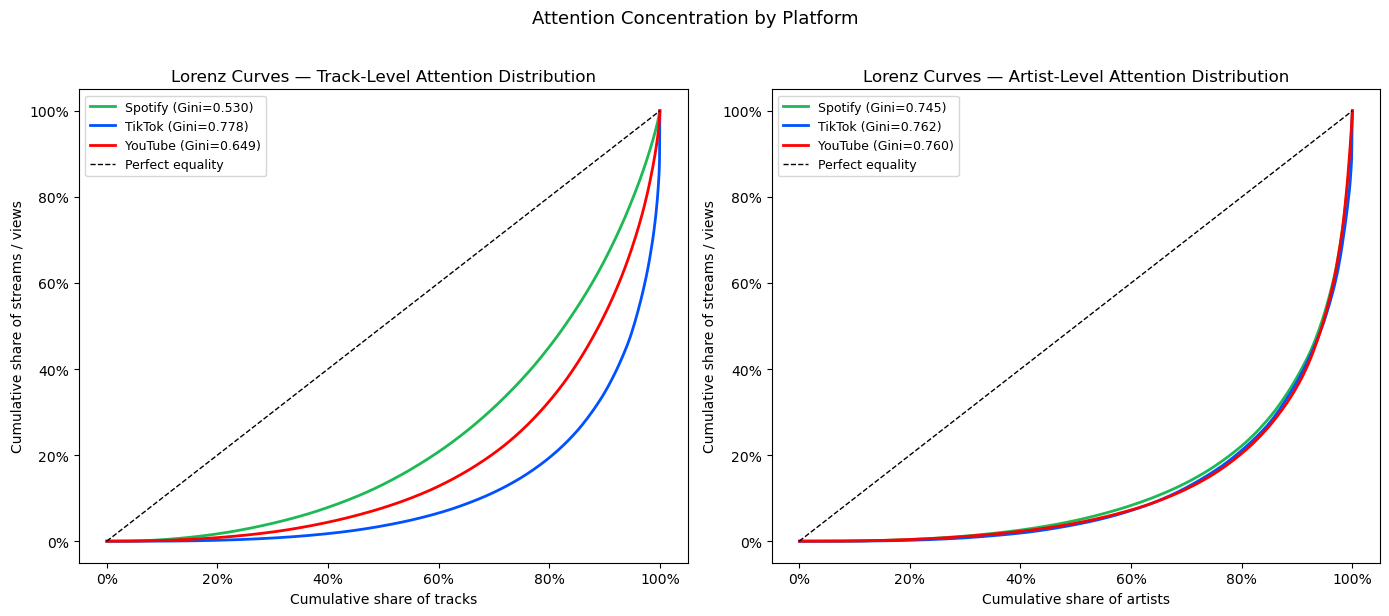

In [7]:
import matplotlib.pyplot as plt

# Define Lorenz curve

def lorenz_curve(arr):
    # Remove nulls and zeros, sort ascending for cumulative share calculation
    arr = np.array(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    arr = arr[arr > 0]
    arr = np.sort(arr)
    cumshare = np.cumsum(arr) / arr.sum()
    popshare = np.arange(1, len(arr) + 1) / len(arr)
    return popshare, cumshare

# Platform colours
colors = {"Spotify": "#1DB954", "TikTok": "#0051ff", "YouTube": "#FF0000"}

# Track and artist level dataframes with output paths
levels = [
    ("Track", df_tracks, "images/lorenz_track.png"),
    ("Artist", df_artists, "images/lorenz_artist.png")
]

# Combined side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (level, df, _) in zip(axes, levels):
    for platform, col in platforms.items():
        x, y = lorenz_curve(df[col])
        ax.plot(x, y, label=f"{platform} (Gini={gini(df[col]):.3f})",
                color=colors[platform], linewidth=2)
    # Perfect equality benchmark
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect equality")
    ax.set_xlabel(f"Cumulative share of {level.lower()}s")
    ax.set_ylabel("Cumulative share of streams / views")
    ax.set_title(f"Lorenz Curves — {level}-Level Attention Distribution")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.legend(fontsize=9)

plt.suptitle("Attention Concentration by Platform", fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("images/lorenz_combined.png", dpi=150, bbox_inches="tight")

# Save individual plots
for level, df, path in levels:
    fig_i, ax_i = plt.subplots(figsize=(7, 5))
    for platform, col in platforms.items():
        x, y = lorenz_curve(df[col])
        ax_i.plot(x, y, label=f"{platform} (Gini={gini(df[col]):.3f})",
                  color=colors[platform], linewidth=2)
    ax_i.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect equality")
    ax_i.set_xlabel(f"Cumulative share of {level.lower()}s")
    ax_i.set_ylabel("Cumulative share of streams / views")
    ax_i.set_title(f"Lorenz Curves — {level}-Level Attention Distribution")
    ax_i.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax_i.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax_i.legend(fontsize=9)
    fig_i.tight_layout()
    fig_i.savefig(path, dpi=150)
    plt.close(fig_i)

plt.show()

The Lorenz curves are consistent with the Gini coefficients above. 
- At **track level** the platform divergence is visually clear — Spotify's curve bows least far from the equality line while TikTok's hugs the axis longest before rising steeply, confirming the highest concentration. 
- At **artist level** the three curves are nearly indistinguishable, reinforcing that superstar concentration is a structural feature common to all platforms rather than an artefact of any single algorithm.

This suggests while platforms differ meaningfully in how attention is distributed by track consumption, the underlying artist-level inequality structure converges. A similar proportion of artists capture a similar share of total attention regardless of platform. 

Therefore, the difference lies not in how skewed the artist distribution is, but in how that attention is delivered whether spread across a catalogue or concentrated into individual tracks. That distinction becomes relevant when we turn to cross-platform comparisons, as set out below.

### 2c — Cross-Platform Artist Positioning: Shares & Ranks

The distribution analysis in 2a and 2b establishes that attention is highly unequal within each platform, but that the structural shape of artist-level inequality converges across platforms. This warrants a closer look at whether individual artist positions are also consistent across platforms or whether the similar aggregate structure masks meaningful divergence at the artist level.

Two complementary lenses are used. 
- First, platform **attention shares** capture what proportion of total platform consumption each artist commands — a scale-normalised measure of relative dominance. 
- Second, platform **ranks** provide an ordinal view of artist positioning. **Rank deltas** surface the artists whose relative standing diverges most sharply between platforms.

Together, share and rank based metricsw across platform pairs reveal strucutral patterns at an artist level

#### 2c(i) — Attention Share Correlation Across Platforms

Each artist's attention share is computed as their proportion of total streams or views on each platform. Shares are log-transformed for visualisation to account for the heavy right skew identified in the Lorenz analysis *(without this, the bulk of artists would be compressed into an unreadable cluster near zero)*. 

Pairwise Pearson correlations and scatterplots are produced for all three platform pairs.

Artist-level platform share correlations (Pearson r):
  Spotify vs TikTok: r = 0.2463
  Spotify vs YouTube: r = 0.8190
  TikTok vs YouTube: r = 0.2050


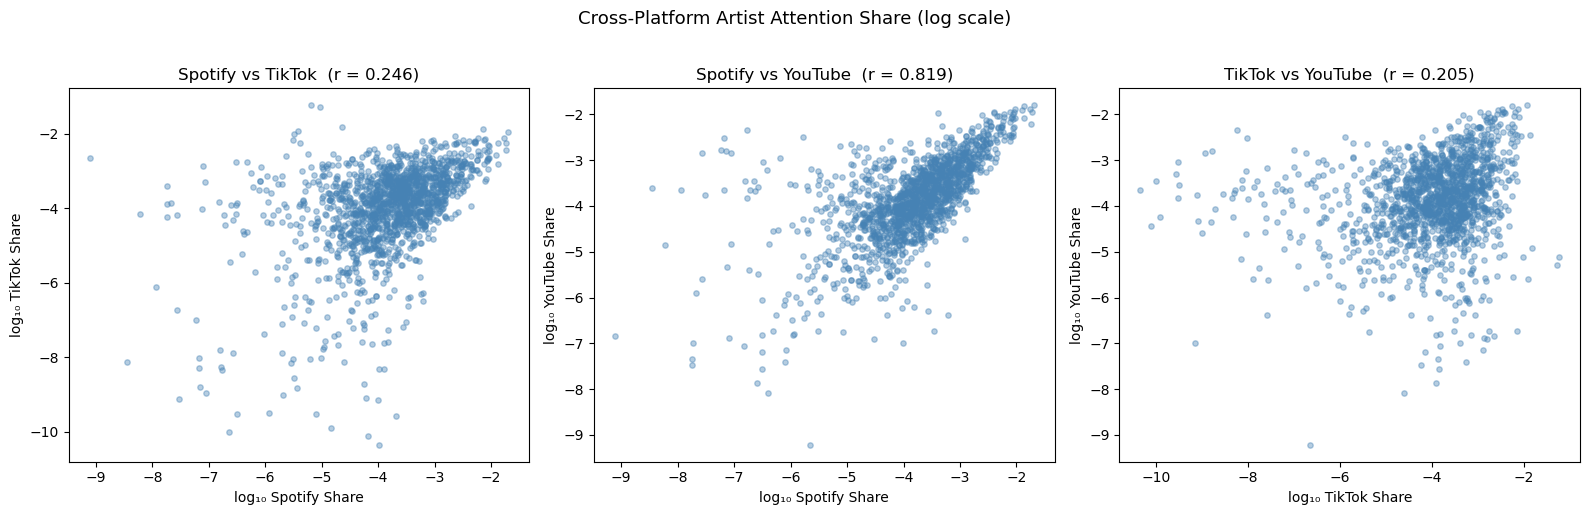

In [8]:
# Compute each artist's share of total platform attention
for platform, col in platforms.items():
    total = df_artists[col].sum()
    df_artists[f"{platform} Share"] = df_artists[col] / total

share_cols = {
    "Spotify": "Spotify Share",
    "TikTok":  "TikTok Share",
    "YouTube": "YouTube Share"
}

pairs = [
    ("Spotify", "TikTok"),
    ("Spotify", "YouTube"),
    ("TikTok",  "YouTube")
]

# Pairwise Pearson correlations on raw shares
print("Artist-level platform share correlations (Pearson r):")
for a, b in pairs:
    r = df_artists[share_cols[a]].corr(df_artists[share_cols[b]])
    print(f"  {a} vs {b}: r = {r:.4f}")

# Log-transformed scatterplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (a, b) in zip(axes, pairs):
    # Filter to artists with non-zero share on both platforms
    mask = (df_artists[share_cols[a]] > 0) & (df_artists[share_cols[b]] > 0)
    x = np.log10(df_artists.loc[mask, share_cols[a]])
    y = np.log10(df_artists.loc[mask, share_cols[b]])
    r = df_artists.loc[mask, share_cols[a]].corr(df_artists.loc[mask, share_cols[b]])
    ax.scatter(x, y, alpha=0.4, s=15, color="steelblue")
    ax.set_xlabel(f"log₁₀ {a} Share")
    ax.set_ylabel(f"log₁₀ {b} Share")
    ax.set_title(f"{a} vs {b}  (r = {r:.3f})")

plt.suptitle("Cross-Platform Artist Attention Share (log scale)", fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("images/share_correlation_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

The share correlations reveal a strongly bifurcated picture of cross-platform alignment:

- **Spotify vs YouTube (r = 0.819)** — by far the strongest relationship, suggesting these two platforms share a similar artist hierarchy at the attention share level. Artists who command a large share of Spotify streams tend to command a comparably large share of YouTube views.
- **Spotify vs TikTok (r = 0.246)** and **TikTok vs YouTube (r = 0.205)** — much lower correlations, indicating that TikTok attention share is largely decoupled from both streaming platforms. High TikTok share is not a reliable predictor of Spotify or YouTube dominance and vice versa.

The log-scale scatterplots make the contrast visual — the Spotify/YouTube panel shows a clear diagonal structure while the TikTok panels show diffuse clouds with a weak positive relationship.

#### 2c(ii) — Rank Correlation & Rank Delta Across Platforms

Artists are ranked within each platform by total streams or views (rank 1 = highest). To compare across platforms:

- **Pairwise Spearman rank correlations** measure the consistency of artist ordering across platforms. 
- **Rank delta** variables are then constructed for each platform pair, defined as the first platform's rank minus the second  and preserving direction so that a positive delta indicates a higher relative position on the first platform and a negative delta indicates the reverse. 

The distribution of rank deltas is visualised as histograms, revealing whether cross-platform divergence is symmetric or skewed toward particular platform pairs.

Artist-level platform rank correlations (Spearman r):
  Spotify vs TikTok: r = 0.4539
  Spotify vs YouTube: r = 0.6702
  TikTok vs YouTube: r = 0.2597


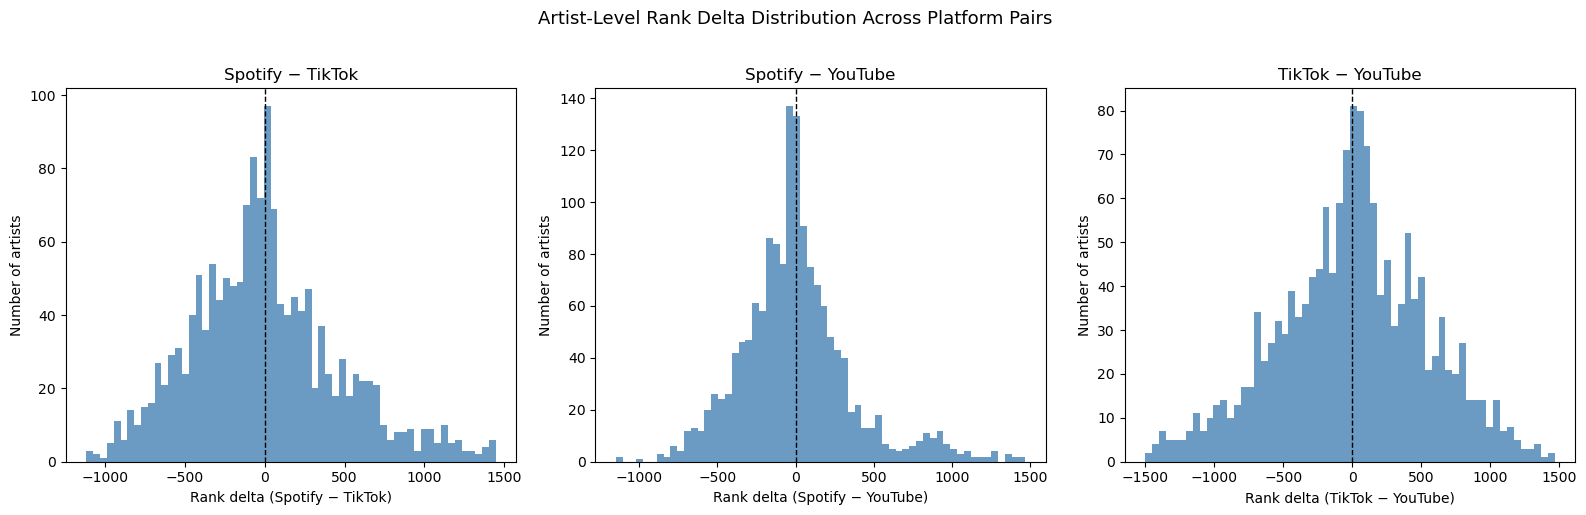

In [9]:
from scipy.stats import spearmanr

# Compute artist-level platform ranks (1 = highest attention)
for platform, col in platforms.items():
    df_artists[f"{platform} Rank"] = df_artists[col].rank(ascending=False, method="min")

rank_cols = {
    "Spotify": "Spotify Rank",
    "TikTok":  "TikTok Rank",
    "YouTube": "YouTube Rank"
}

# Pairwise Spearman rank correlations
print("Artist-level platform rank correlations (Spearman r):")
for a, b in pairs:
    r, _ = spearmanr(df_artists[rank_cols[a]], df_artists[rank_cols[b]])
    print(f"  {a} vs {b}: r = {r:.4f}")

# Rank delta variables — signed, direction preserved
df_artists["Rank Delta Spotify-TikTok"]  = df_artists["Spotify Rank"] - df_artists["TikTok Rank"]
df_artists["Rank Delta Spotify-YouTube"] = df_artists["Spotify Rank"] - df_artists["YouTube Rank"]
df_artists["Rank Delta TikTok-YouTube"]  = df_artists["TikTok Rank"]  - df_artists["YouTube Rank"]

delta_cols = {
    "Spotify − TikTok":  "Rank Delta Spotify-TikTok",
    "Spotify − YouTube": "Rank Delta Spotify-YouTube",
    "TikTok − YouTube":  "Rank Delta TikTok-YouTube"
}

# Rank delta histograms
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, col) in zip(axes, delta_cols.items()):
    ax.hist(df_artists[col].dropna(), bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel(f"Rank delta ({label})")
    ax.set_ylabel("Number of artists")
    ax.set_title(label)

plt.suptitle("Artist-Level Rank Delta Distribution Across Platform Pairs", fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("images/rank_delta_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

The Spearman rank correlations are consistent with the share analysis but reveal somewhat more cross-platform order than raw shares suggest:

- **Spotify vs YouTube (r = 0.670)** — moderate to strong rank alignment, confirming that artist ordering on these two platforms is broadly consistent.
- **Spotify vs TikTok (r = 0.454)** — weak to moderate alignment, indicating partial overlap in artist ordering but significant divergence for a meaningful subset of artists.
- **TikTok vs YouTube (r = 0.260)** — the weakest pairing, suggesting TikTok rank order has the least in common with either streaming platform.

The rank delta histograms are approximately centred around zero for all three pairs, indicating no systematic directional bias — artists are as likely to rank higher on one platform as the other. However the distributions have fat tails, particularly in the TikTok pairings, pointing to a sizeable group of artists with substantially divergent cross-platform positions.

## Section 3 — Latent Attention Structures: Artist Clustering

With cross-platform attention shares, ranks, and rank deltas established in Section 2, we turn to the question of whether consistent artist archetypes exist within that distribution — groups whose cross-platform attention profiles reflect structural patterns rather than individual variation.

Section 3 covers three related analyses:

- **3a — Feature construction & optimal cluster selection** builds the nine-feature clustering matrix across platform dominance, within-platform positioning, and cross-platform divergence dimensions, and selects optimal k via silhouette scoring.
- **3b — Cluster assignment & initial inspection** fits the final K-means model at k=7, assigns cluster labels to the artist dataframe, and profiles each cluster by its top artists across platform consumption.
- **3c — Cluster profiling & interpretation** characterises each cluster through platform share distributions, engagement and playlist density metrics, and a normalised summary heatmap — surfacing the defining features of each archetype.

Together these analyses identify seven distinct artist archetypes whose cross-platform attention profiles range from globally dominant superstars to TikTok-native viral acts, YouTube-dominant regional artists, and catalogue-heavy legacy streaming acts.

### 3a — Feature Construction & Optimal Cluster Selection

Nine features are constructed across three dimensions of cross-platform attention:

- **Platform dominance** (`Spotify Share`, `YouTube Share`, `TikTok Share`) — each artist's share of total platform consumption, capturing how much of the attention pie they command on each platform
- **Within-platform positioning** (`Spotify Rank`, `YouTube Rank`, `TikTok Rank`) — ordinal rank within each platform, capturing where an artist sits relative to peers regardless of absolute share magnitude
- **Cross-platform divergence** (`Rank Delta Spotify-TikTok`, `Rank Delta Spotify-YouTube`, `Rank Delta TikTok-YouTube`) — signed rank differences across platform pairs, capturing whether an artist's relative standing is consistent or divergent across platforms

These three dimensions are deliberately distinct. Share captures scale of dominance. Rank captures positional standing within a platform's attention hierarchy. Rank delta captures the degree to which that standing diverges across platforms — an artist can have low shares everywhere but still rank consistently or inconsistently. Together they give K-means a feature space that reflects both how much attention an artist commands and where and how consistently they command it.

All nine features are standardised to zero mean and unit variance. Optimal k is selected by maximising the silhouette score — a measure of how similar each artist is to its own cluster relative to the nearest alternative, ranging from -1 (misclassified) to 1 (well separated).

Artists available for clustering: 1,534
Feature matrix shape: (1534, 9)
Optimal k: 7  |  Silhouette score: 0.2966


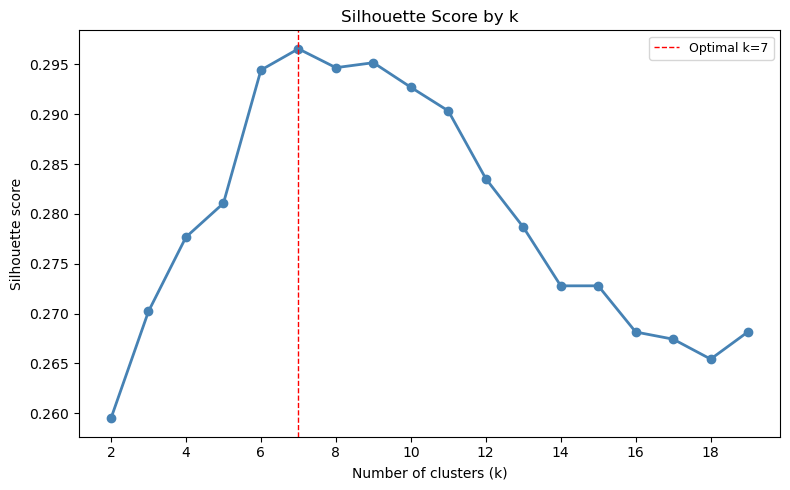

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(98)

# Nine features across dominance, positioning and cross-platform divergence
feature_cols = [
    "Spotify Share",
    "YouTube Share",
    "TikTok Share",
    "Spotify Rank",
    "YouTube Rank",
    "TikTok Rank",
    "Rank Delta Spotify-TikTok",
    "Rank Delta Spotify-YouTube",
    "Rank Delta TikTok-YouTube"
]

# Drop nulls — zeros are valid observations
df_cluster = df_artists.dropna(subset=feature_cols).copy()

# Standardise all 9 features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[feature_cols])

print(f"Artists available for clustering: {len(df_cluster):,}")
print(f"Feature matrix shape: {X_scaled.shape}")

# Evaluate k from 2 to 20
k_range = range(2, 20)
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=98, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Identify optimal k
optimal_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f"Optimal k: {optimal_k}  |  Silhouette score: {max(silhouettes):.4f}")

# Silhouette plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), silhouettes, "o-", color="steelblue", linewidth=2)
ax.axvline(optimal_k, color="red", linestyle="--", linewidth=1, label=f"Optimal k={optimal_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette Score by k")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("images/kmeans_silhouette.png", dpi=150)
plt.show()

### 3b — Cluster Assignment & Initial Inspection

The final K-means model is fitted at k=7. Cluster labels are assigned to the artist dataframe and each cluster is profiled by its top artists ranked by Spotify Streams. Total consumption is reported in billions (for dominant platforms) to aid readability, split across Spotify, TikTok, and YouTube — giving an immediate sense of where each cluster's artists are most natively present and how their attention is distributed across platforms.

In [11]:
# Fit final model at k=7
km_final = KMeans(n_clusters=7, random_state=98, n_init=10)
df_cluster["Cluster"] = km_final.fit_predict(X_scaled)

# Merge cluster labels back into df_artists
df_artists = df_artists.merge(
    df_cluster[["Artist", "Cluster"]],
    on="Artist", how="left"
)

# Helper — format raw numbers into readable scale
def fmt(n):
    if pd.isna(n):
        return "—"
    if n >= 1e9:
        return f"{n/1e9:.2f}B"
    if n >= 1e6:
        return f"{n/1e6:.1f}M"
    return f"{n:,.0f}"

# Top 10 artists per cluster by Spotify Streams

for c in sorted(df_artists["Cluster"].dropna().unique()):
    print(f"\n{'='*65}")
    print(f"  Cluster {int(c)}  —  {(df_artists['Cluster']==c).sum()} artists")
    print(f"{'='*65}")
    top = (
        df_artists[df_artists["Cluster"] == c]
        .nlargest(10, "Spotify Streams")
        [["Artist", "Spotify Streams", "TikTok Views", "YouTube Views"]]
        .copy()
    )
    top["Spotify Streams"] = top["Spotify Streams"].apply(fmt)
    top["TikTok Views"]    = top["TikTok Views"].apply(fmt)
    top["YouTube Views"]   = top["YouTube Views"].apply(fmt)
    print(top.to_string(index=False))


  Cluster 0  —  415 artists
                  Artist Spotify Streams TikTok Views YouTube Views
              Noah Kahan           1.40B       321.7M        110.4M
                   Riton           1.38B       306.1M        103.4M
      Axwell /\ Ingrosso           1.35B        87.0M         68.2M
             Frank Ocean           1.30B       442.1M        158.0M
            Dominic Fike           1.26B       281.6M        135.5M
                 JP Saxe           1.15B       947.8M         96.5M
                     M83           1.08B        1.01B         82.4M
Lilly Wood and The Prick           1.07B       138.6M       631,896
       A Great Big World           1.06B       339.3M        113.3M
     Of Monsters and Men           1.05B       162.0M         95.5M

  Cluster 1  —  317 artists
        Artist Spotify Streams TikTok Views YouTube Views
     Rosa Linn           2.21B        5.57B         28.8M
        ACRAZE          805.0M       10.37B        117.7M
        zzoilo      

Seven clusters emerge from the K-means solution, each reflecting a distinct cross-platform attention archetype. Cluster labels are assigned based on the dominant platform profile and consumption pattern of member artists.

- **Cluster 0 — Mid-Tier Spotify** *(415 artists)*: The largest cluster by count. Moderate Spotify streams, limited TikTok and YouTube presence. Noah Kahan, Frank Ocean, M83 — indie, alternative and niche artists with a core streaming audience but limited cross-platform viral footprint. The long-tail of the mainstream catalogue.

- **Cluster 1 — TikTok Natives** *(317 artists)*: Moderate to low Spotify streams but disproportionately large TikTok view counts — yneheart, Tai Verdes, ACRAZE, Echosmith. These artists' audiences are primarily TikTok-based, consistent with the viral-first discovery pattern. YouTube presence is minimal.

- **Cluster 2 — YouTube Dominant** *(143 artists)*: Low Spotify streams but very high YouTube views — Jubin Nautiyal, Atif Aslam, Neha Kakkar. Predominantly South Asian and regional artists whose audiences consume music primarily through YouTube. TikTok presence is limited.

- **Cluster 3 — Global Superstars** *(50 artists)*: The most dominant cluster by absolute volume. Bad Bunny, Taylor Swift, Drake, The Weeknd — artists with multi-billion stream and view counts across all three platforms simultaneously. Defined by scale and cross-platform ubiquity rather than any single platform dependency.

- **Cluster 4 — TikTok Viral Anomalies** *(2 artists)*: An extreme outlier cluster. The King Khan & BBQ Show and Kevin MacLeod have negligible Spotify and YouTube presence but generate hundreds of billions of TikTok views — driven by audio being used as background sound or meme content rather than deliberate artist consumption. A structurally distinct category.


- **Cluster 5 — Mainstream Streaming Tier** *(342 artists)*: Strong and balanced across all three platforms with Spotify as the lead platform. Lewis Capaldi, SZA, Pop Smoke, Lil Baby — commercially mainstream artists with broad multi-platform presence. The largest high-volume cluster.

- **Cluster 6 — Legacy Streaming & YouTube** *(265 artists)*: Solid Spotify and YouTube presence but low TikTok engagement relative to overall scale. Arctic Monkeys, Linkin Park, Kygo, Passenger — catalogue-heavy or legacy acts whose audiences predate TikTok and engage primarily through streaming and YouTube.



### 3c — Cluster Profiling & Interpretation

With cluster labels assigned, we now characterise each group across dimensions not used directly in the clustering — engagement behaviour, playlist density, and the full distribution of platform shares. 

Three visualisations are produced in sequence:

- **Platform attention share distributions** — boxplots of Spotify, TikTok and YouTube share by cluster, showing both central tendency and within-cluster spread
- **Engagement and playlist density** — derived metrics capturing audience interaction intensity (likes/views on TikTok and YouTube) and playlist-driven reach (playlist reach/streams or views on Spotify and YouTube), revealing how attention is delivered within each cluster
- **Normalised summary heatmap** — z-scored cluster means across all profiling dimensions plus the rank delta features from clustering, providing a consolidated view of each cluster's signature relative to the overall artist population

These provide a comprehensive view over the latent artist groups based on attention/activity data.

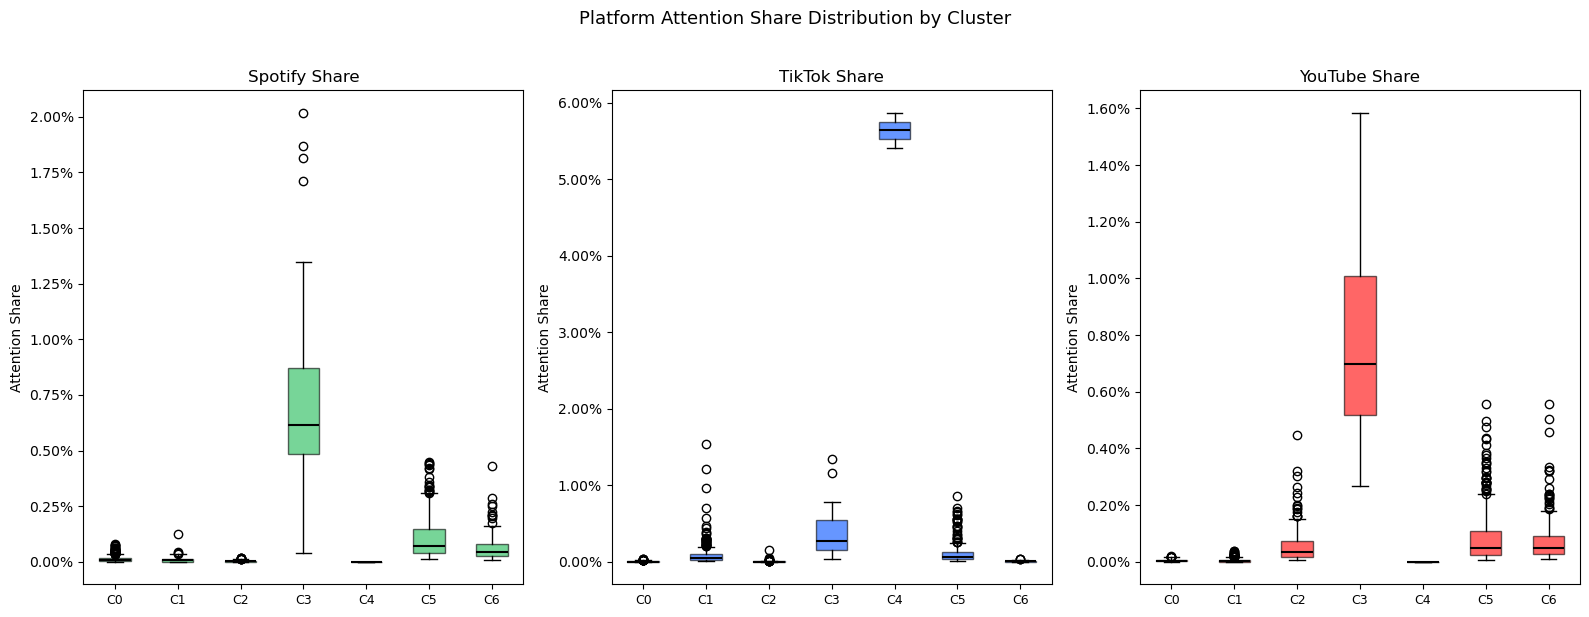

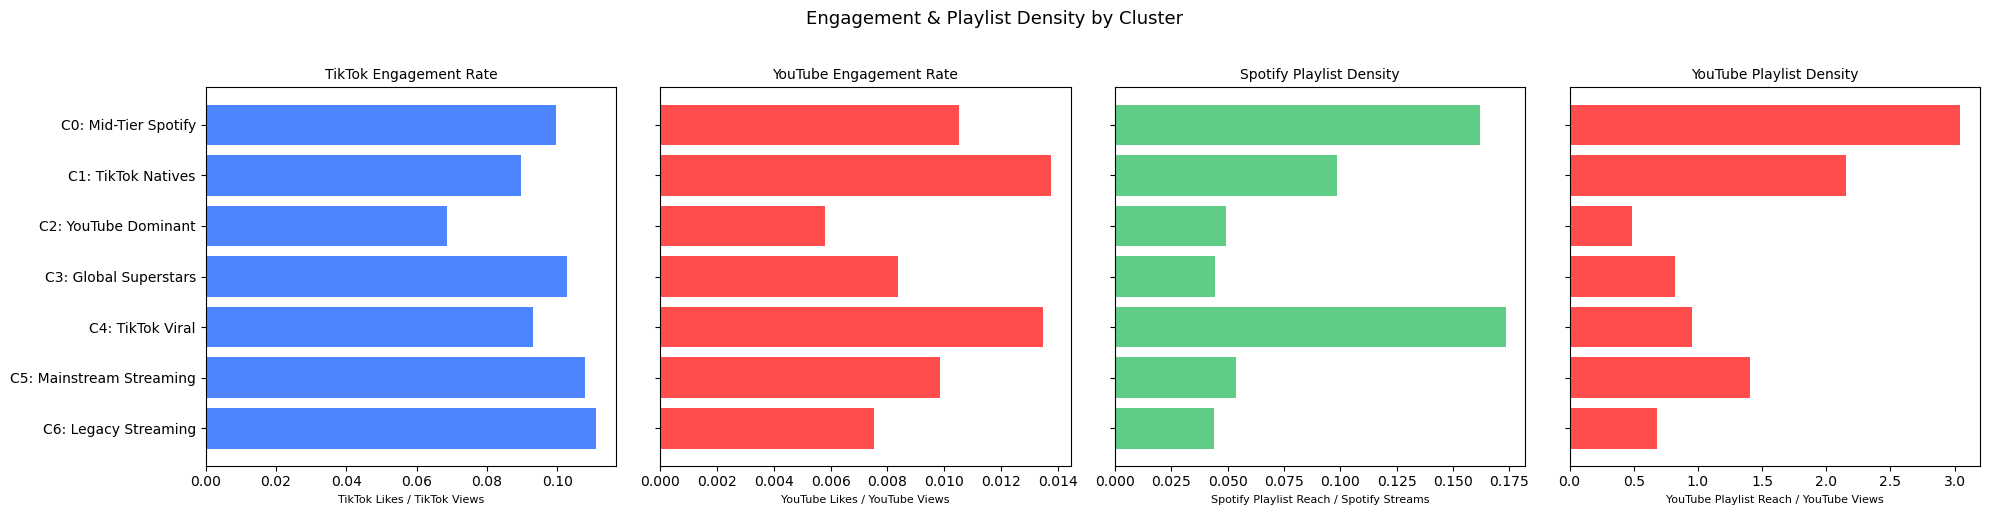

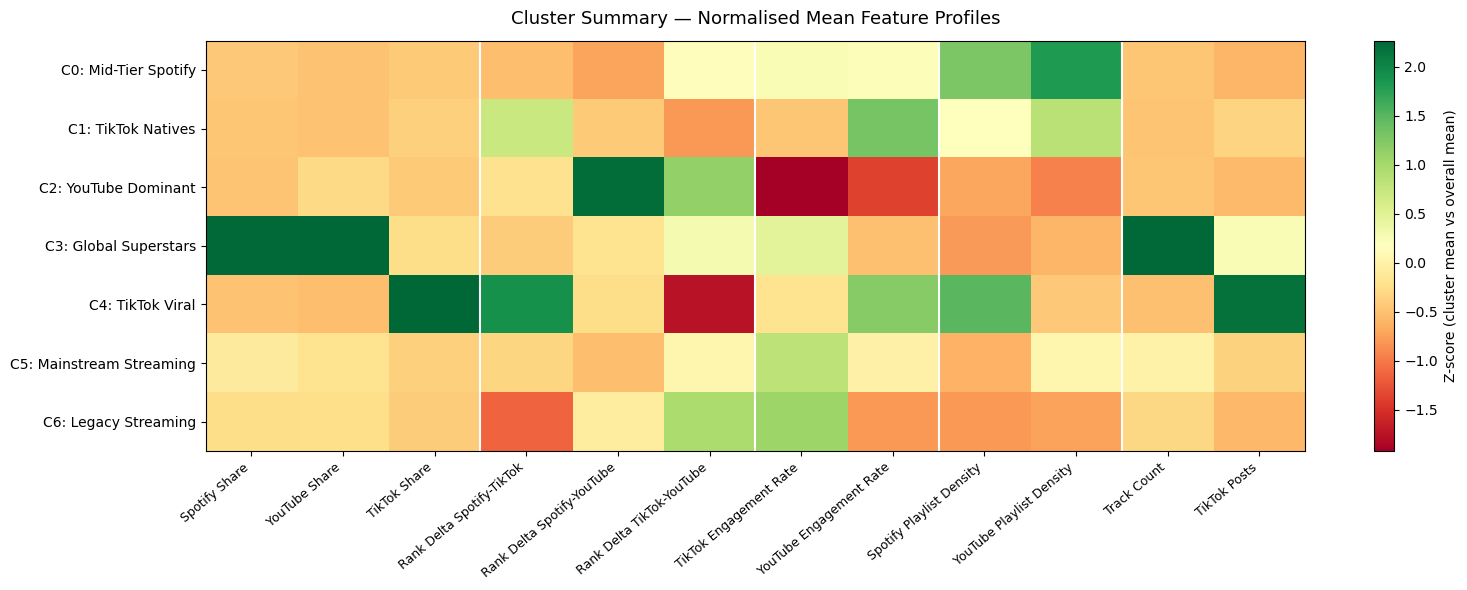

In [12]:
# Cluster labels
cluster_names = {
    0: "C0: Mid-Tier Spotify",
    1: "C1: TikTok Natives",
    2: "C2: YouTube Dominant",
    3: "C3: Global Superstars",
    4: "C4: TikTok Viral",
    5: "C5: Mainstream Streaming",
    6: "C6: Legacy Streaming"
}
df_artists["Cluster Label"] = df_artists["Cluster"].map(cluster_names)

# Derived engagement and reach metrics
df_artists["TikTok Engagement Rate"]    = df_artists["TikTok Likes"]         / df_artists["TikTok Views"]
df_artists["YouTube Engagement Rate"]   = df_artists["YouTube Likes"]        / df_artists["YouTube Views"]
df_artists["Spotify Playlist Density"]  = df_artists["Spotify Playlist Reach"] / df_artists["Spotify Streams"]
df_artists["YouTube Playlist Density"]  = df_artists["YouTube Playlist Reach"]  / df_artists["YouTube Views"]

# Cluster order — C0 to C6 numerically
cluster_order = [
    "C0: Mid-Tier Spotify",
    "C1: TikTok Natives",
    "C2: YouTube Dominant",
    "C3: Global Superstars",
    "C4: TikTok Viral",
    "C5: Mainstream Streaming",
    "C6: Legacy Streaming"
]

# 1. Platform share boxplots
share_vars   = ["Spotify Share",  "TikTok Share",  "YouTube Share"]
share_colors = ["#1DB954", "#0051ff", "#FF0000"]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, col, color in zip(axes, share_vars, share_colors):
    data = [df_artists[df_artists["Cluster Label"] == c][col].dropna().values
            for c in cluster_order]
    bp = ax.boxplot(data, patch_artist=True, vert=True,
                    medianprops=dict(color="black", linewidth=1.5))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticklabels([c.split(":")[0] for c in cluster_order], fontsize=9)
    ax.set_title(col)
    ax.set_ylabel("Attention Share")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2%}"))

plt.suptitle("Platform Attention Share Distribution by Cluster", fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("images/cluster_share_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Engagement and playlist density bar charts 
eng_cols = [
    "TikTok Engagement Rate",
    "YouTube Engagement Rate",
    "Spotify Playlist Density",
    "YouTube Playlist Density"
]
eng_colors = ["#0051ff", "#FF0000", "#1DB954", "#FF0000"]
eng_xlabels = [
    "TikTok Likes / TikTok Views",
    "YouTube Likes / YouTube Views",
    "Spotify Playlist Reach / Spotify Streams",
    "YouTube Playlist Reach / YouTube Views"
]

eng_means = df_artists.groupby("Cluster Label")[eng_cols].mean().loc[cluster_order]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col, color, xlabel in zip(axes, eng_cols, eng_colors, eng_xlabels):
    ax.barh(cluster_order, eng_means[col].values, color=color, alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_title(col, fontsize=10)
    ax.invert_yaxis()
    # Only show y labels on first panel
    if col != eng_cols[0]:
        ax.set_yticklabels([])

plt.suptitle("Engagement & Playlist Density by Cluster", fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("images/cluster_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Summary heatmap
heatmap_cols = [
    # Shares
    "Spotify Share",
    "YouTube Share",
    "TikTok Share",
    # Rank deltas
    "Rank Delta Spotify-TikTok",
    "Rank Delta Spotify-YouTube",
    "Rank Delta TikTok-YouTube",
    # Engagement
    "TikTok Engagement Rate",
    "YouTube Engagement Rate",
    # Playlist density
    "Spotify Playlist Density",
    "YouTube Playlist Density",
    # Supplementary
    "Track Count",
    "TikTok Posts"
]

cluster_means   = df_artists.groupby("Cluster Label")[heatmap_cols].mean()
cluster_means_z = (cluster_means - cluster_means.mean()) / cluster_means.std()
cluster_means_z = cluster_means_z.loc[cluster_order]

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(cluster_means_z.values, aspect="auto", cmap="RdYlGn")
ax.set_xticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(len(cluster_order)))
ax.set_yticklabels(cluster_order, fontsize=10)
plt.colorbar(im, ax=ax, label="Z-score (cluster mean vs overall mean)")
ax.set_title("Cluster Summary — Normalised Mean Feature Profiles", fontsize=13, pad=12)

# Light vertical dividers between feature groups
for x in [2.5, 5.5, 7.5, 9.5]:
    ax.axvline(x, color="white", linewidth=1.5)

plt.tight_layout()
plt.savefig("images/cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

*Platform Attention Share Distributions*
- C2 (YouTube Dominant) shows the widest YouTube share interquartile range — a diverse group of regional and non-English language artists with disproportionate YouTube audiences relative to their Spotify footprint
- C3 (Global Superstars) commands the largest and most dispersed Spotify share — individual artists hold up to 2% of total platform streams, extraordinary given 1,534 artists in the dataset
- C4 (TikTok Viral) is the mirror image: negligible Spotify and YouTube share but ~5.5% TikTok share concentrated in just two artists whose audio circulates as background or meme content
- C5 and C6 are broadly similar across all three share panels, differentiated more by engagement behaviour and rank positioning than raw platform dominance

*Engagement & Playlist Density*
- C0 (Mid-Tier Spotify) has the highest Spotify playlist density (reach per stream) — consumption driven by editorial and algorithmic playlist placement rather than organic artist discovery
- C1 (TikTok Natives) and C4 (TikTok Viral) post the highest YouTube engagement rates despite minimal YouTube share — when their audiences engage on YouTube they do so actively, suggesting intentional rather than incidental viewing
- C2 (YouTube Dominant) has the lowest YouTube engagement rate despite high view volumes — characteristic of passive music video consumption rather than active fan interaction
- TikTok engagement rates are broadly uniform across clusters (~8–11%); C2 (YouTube Dominant) is the exception — lower TikTok engagement consistent with audiences who use the platform passively if at all

*Normalised Summary Heatmap*
- C3 (Global Superstars) is the only cluster above average across every feature simultaneously — dominant shares, high track count, strong engagement across both platforms
- C4 (TikTok Viral) is the sharpest outlier: extreme TikTok share and TikTok posts, deeply below average on Spotify and YouTube, and the most negative Rank Delta Spotify-TikTok in the dataset
- C6 (Legacy Streaming) is defined by a strongly negative Rank Delta Spotify-TikTok — these artists rank materially higher on Spotify than TikTok, reflecting catalogue audiences that predate short-form video
- C5 (Mainstream Streaming) sits closest to the overall mean across all features — the most balanced cluster, with no single platform dependency or engagement anomaly